In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, feos, si_units as si, matplotlib.ticker as ticker, json
import os, shutil, csv, sys
from io import StringIO
from itertools import chain
from scipy.optimize import least_squares
from scipy.optimize import minimize_scalar

sys.path.append("..")
import PLOT_SETTINGS as ps

In [25]:
from feos import ad

ImportError: cannot import name 'ad' from 'feos' (/home/darshan/A6/py_A6/lib/python3.12/site-packages/feos/__init__.py)

In [12]:
print(dir(feos))

['Adsorption1D', 'Adsorption3D', 'BinaryRecord', 'BinarySegmentRecord', 'ChemicalRecord', 'Contributions', 'DFTSolver', 'DFTSolverLog', 'EquationOfState', 'EquationOfStateAD', 'ExternalPotential', 'FMTVersion', 'GcParameters', 'Geometry', 'HelmholtzEnergyFunctional', 'Identifier', 'IdentifierOption', 'PairCorrelation', 'Parameters', 'PhaseDiagram', 'PhaseDiagramHetero', 'PhaseEquilibrium', 'PlanarInterface', 'Pore1D', 'Pore2D', 'Pore3D', 'PureRecord', 'SegmentRecord', 'SmartsRecord', 'SolvationProfile', 'State', 'StateVec', 'SurfaceTensionDiagram', 'Verbosity', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'bubble_point_pressure_derivatives', 'dew_point_pressure_derivatives', 'equilibrium_liquid_density_derivatives', 'feos', 'liquid_density_derivatives', 'vapor_pressure_derivatives']


In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    binary_data = [{ "id1": {"name": "argon",},
          "id2": {"name": "carbon dioxide"},
          "k_ij": kij,}]
    
    #tmp_file = "binary_temp.json"
    with open("binary_temp.json", 'w') as f:
        json.dump(binary_data, f, indent=4)
    
    p = feos.Parameters.from_json(
        ["argon", "carbon dioxide"], 
        "parameters.json",
        binary_path="binary_temp.json")
    
    return feos.EquationOfState.pcsaft(p)

In [3]:
def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return feos.estimator.cost(eos_from_kij(kij), estimator)

In [4]:

def VLE_PLOT(data, temperature, kij):
    
    """
    Generates a VLE plot for a specific temperature using experimental data and PC-SAFT estimate.

    Parameters:
    - data: pandas DataFrame with columns including 't' (temperature), 'x1', 'y1', and 'p'
    - temperature: target temperature to plot (same units as 't' in data)
    - kij: binary interaction parameter
    """

    isotherm = data[data["t_K"] == temperature]

    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()

    i = 0

    ax.plot(1-isotherm.x1_AR, isotherm.p_bar,
        color='blue', marker=ps.markers[i % len(ps.markers)],
        linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,
        label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

    ax.plot(1-isotherm.y1_AR, isotherm.p_bar,
    color='red', marker=ps.markers[i % len(ps.markers)],
    linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth)

    vle = feos.PhaseDiagram.binary_vle(eos_from_kij(kij),
    temperature * si.KELVIN,npoints=100)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / si.BAR,
    color='red', linewidth=ps.linewidth, linestyle="-",
    label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / si.BAR,
    color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / si.BAR).min()/1.3, (vle.liquid.pressure / si.BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right', ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
    
    output_dir = "KIJ_PLOTS"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
    ps.save_figure(fig, os.path.join(output_dir, f"vle_T{int(temperature)}K_kij{kij:.3f}.png"))

In [5]:
parameters  = feos.Parameters.from_json(["argon", "carbon dioxide"], "parameters.json")
pcsaft      = feos.EquationOfState.pcsaft(parameters)
data        = pd.read_csv("EXP_DATA_CO2_AR.csv", delimiter=",")

print(data.head())
parameters

    p_bar   x1_AR   y1_AR     t_K                 source
0  18.945  0.0197  0.5685  223.07  Lasala et al., 2016\r
1  28.639  0.0366  0.6878  223.07  Lasala et al., 2016\r
2  39.899  0.0576  0.7500  223.07  Lasala et al., 2016\r
3  48.720  0.0799  0.7744  223.07  Lasala et al., 2016\r
4  58.570  0.1050  0.7930  223.07  Lasala et al., 2016\r


|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|argon|39.962|1.0|3.37751|117.80903|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|

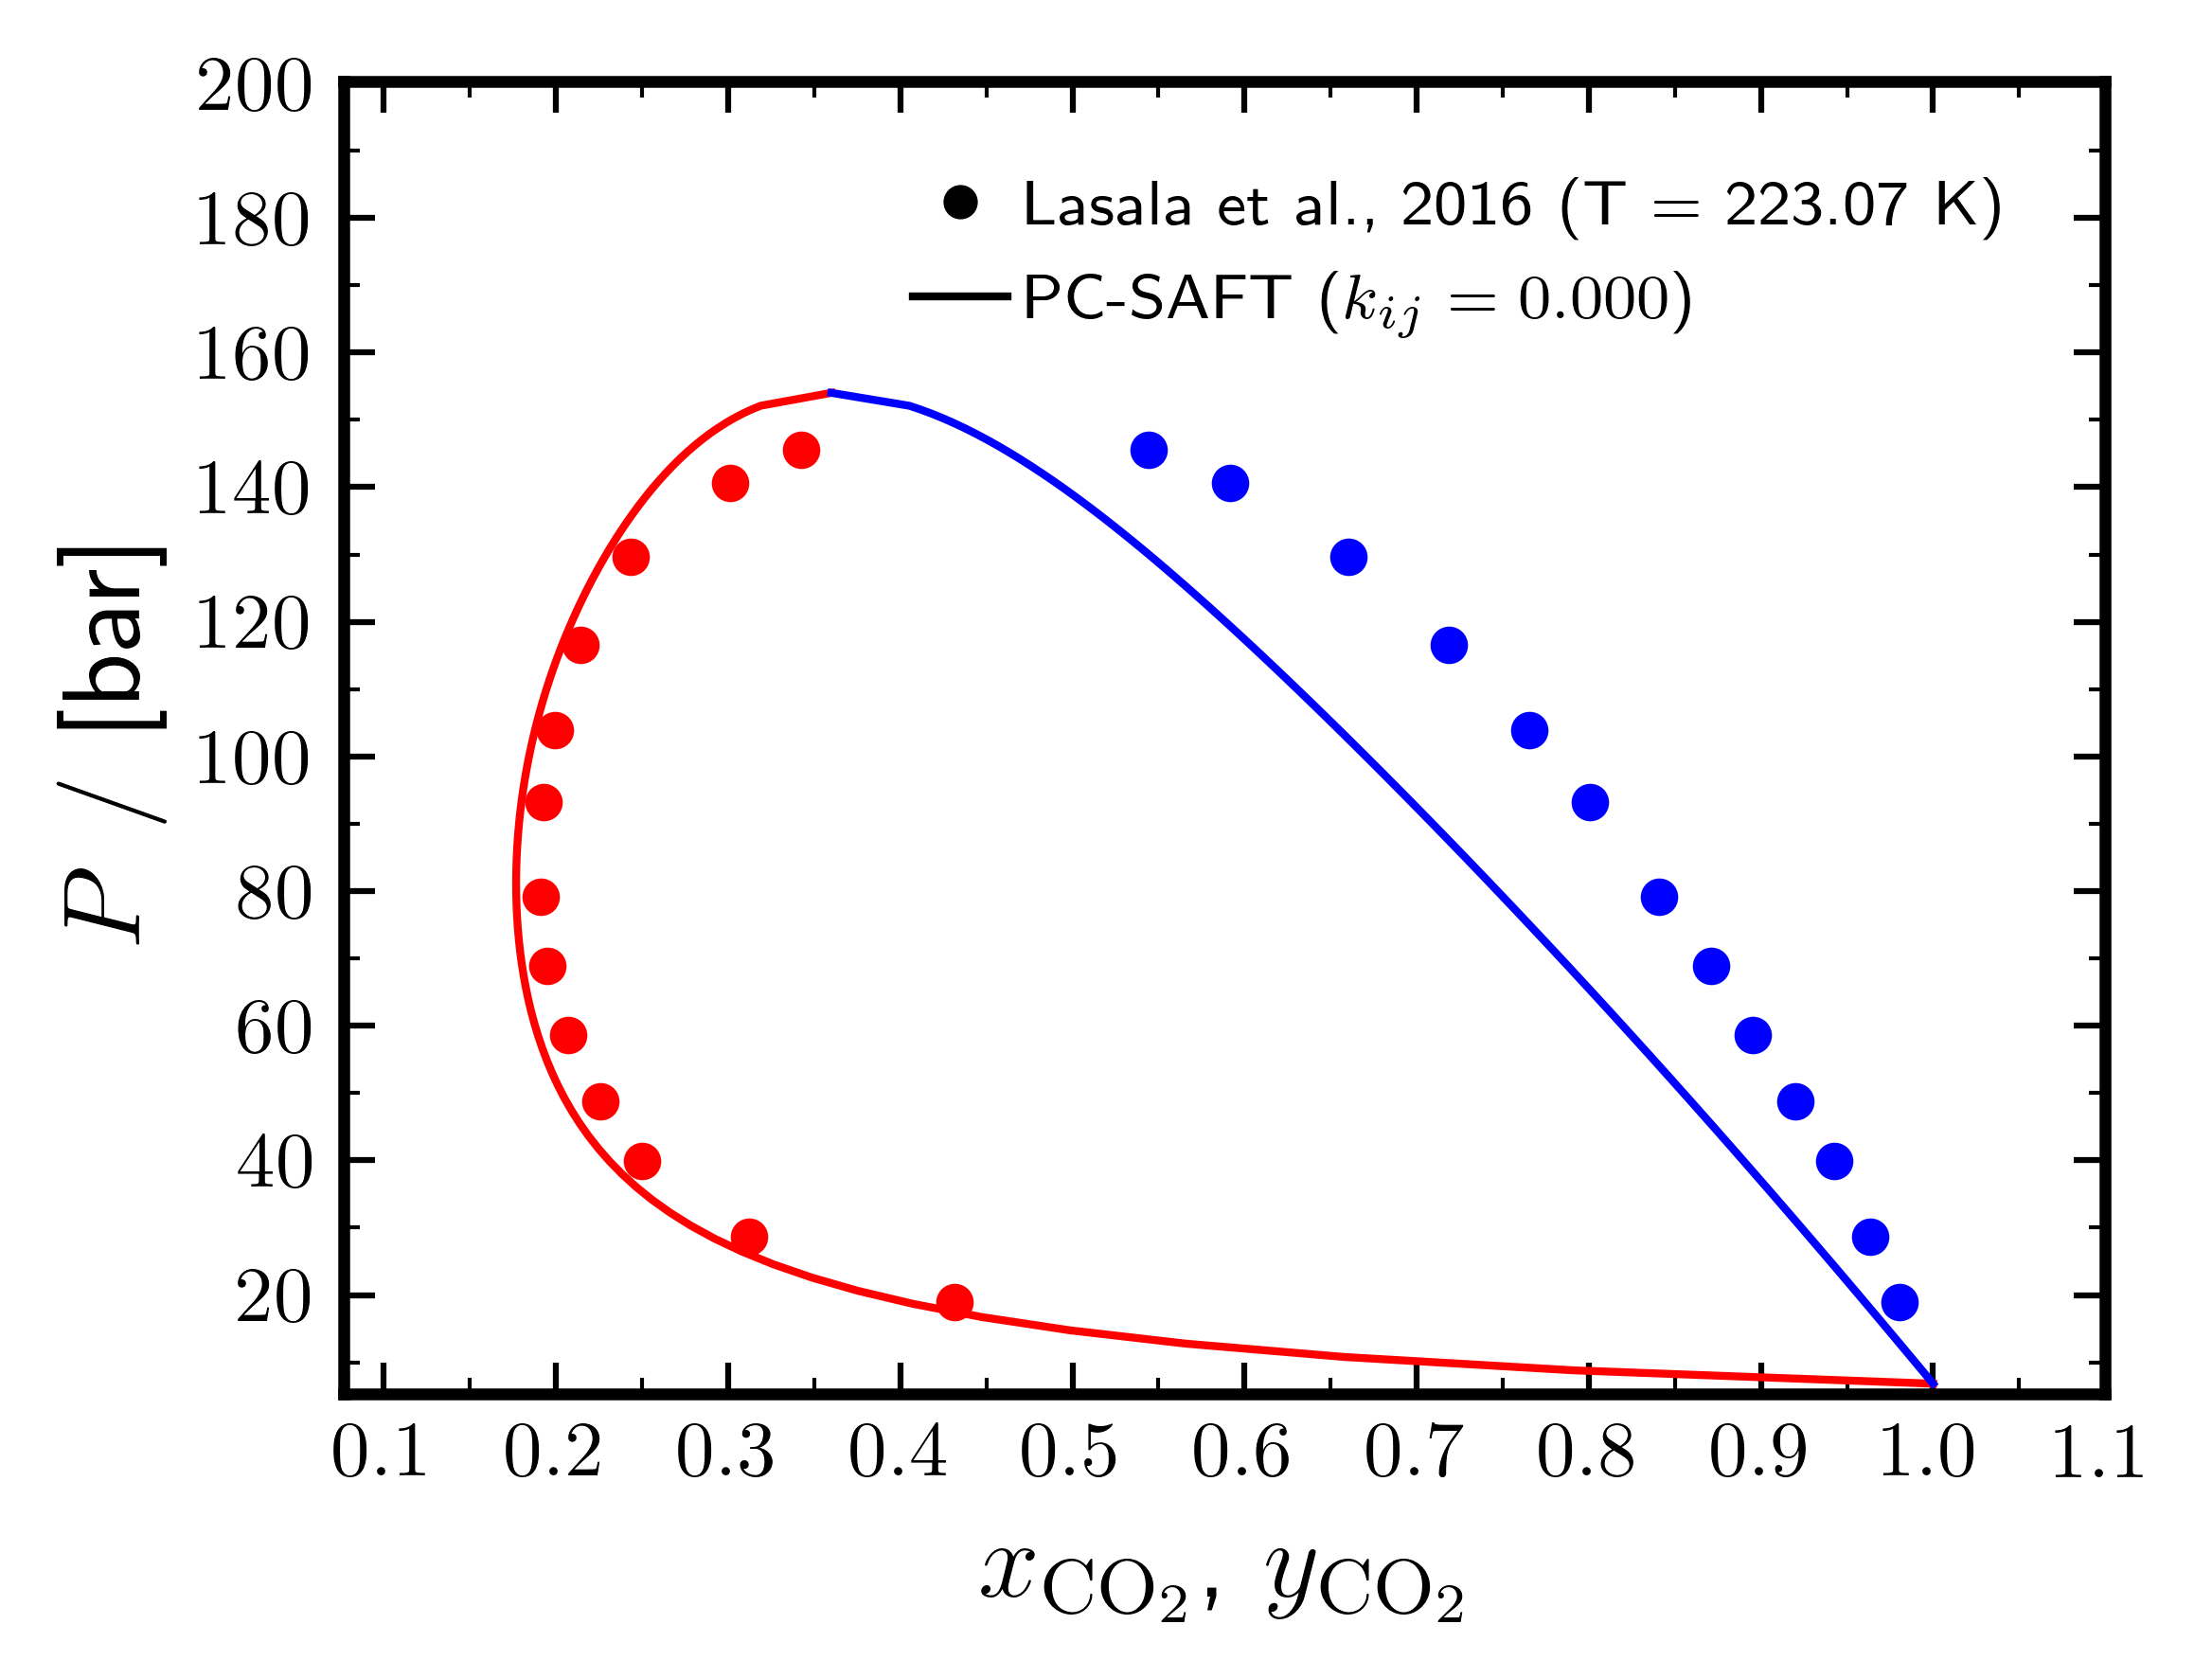

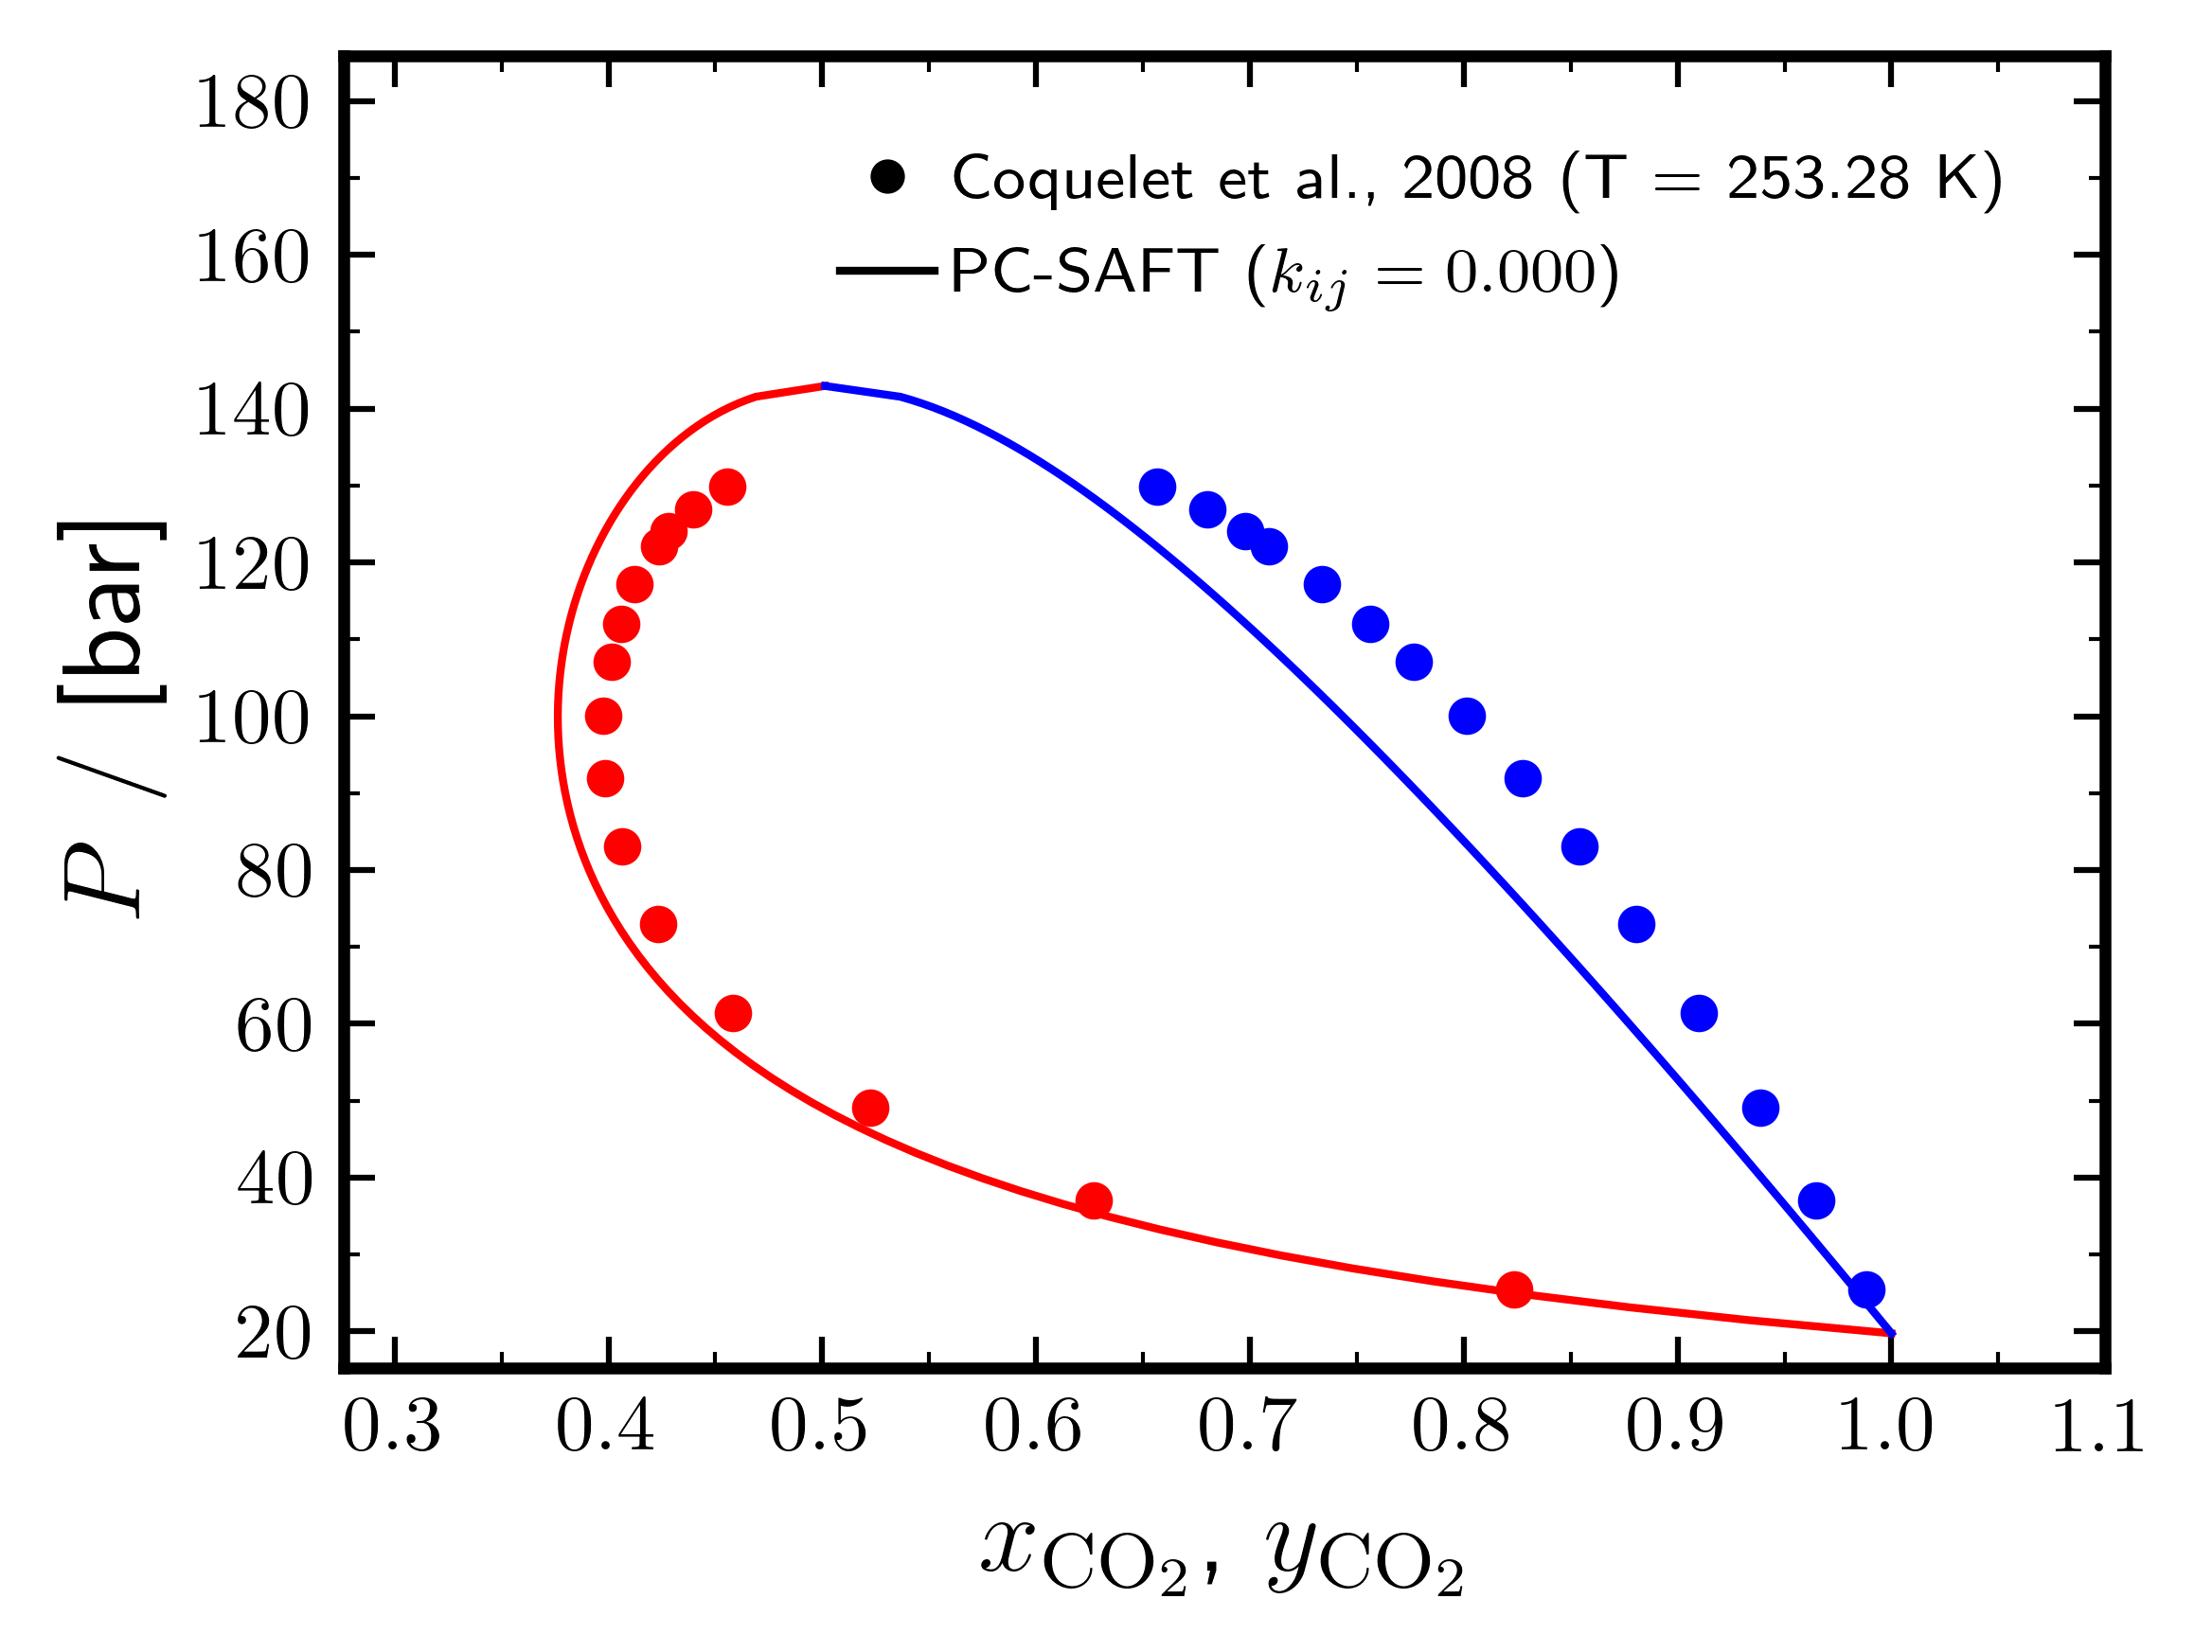

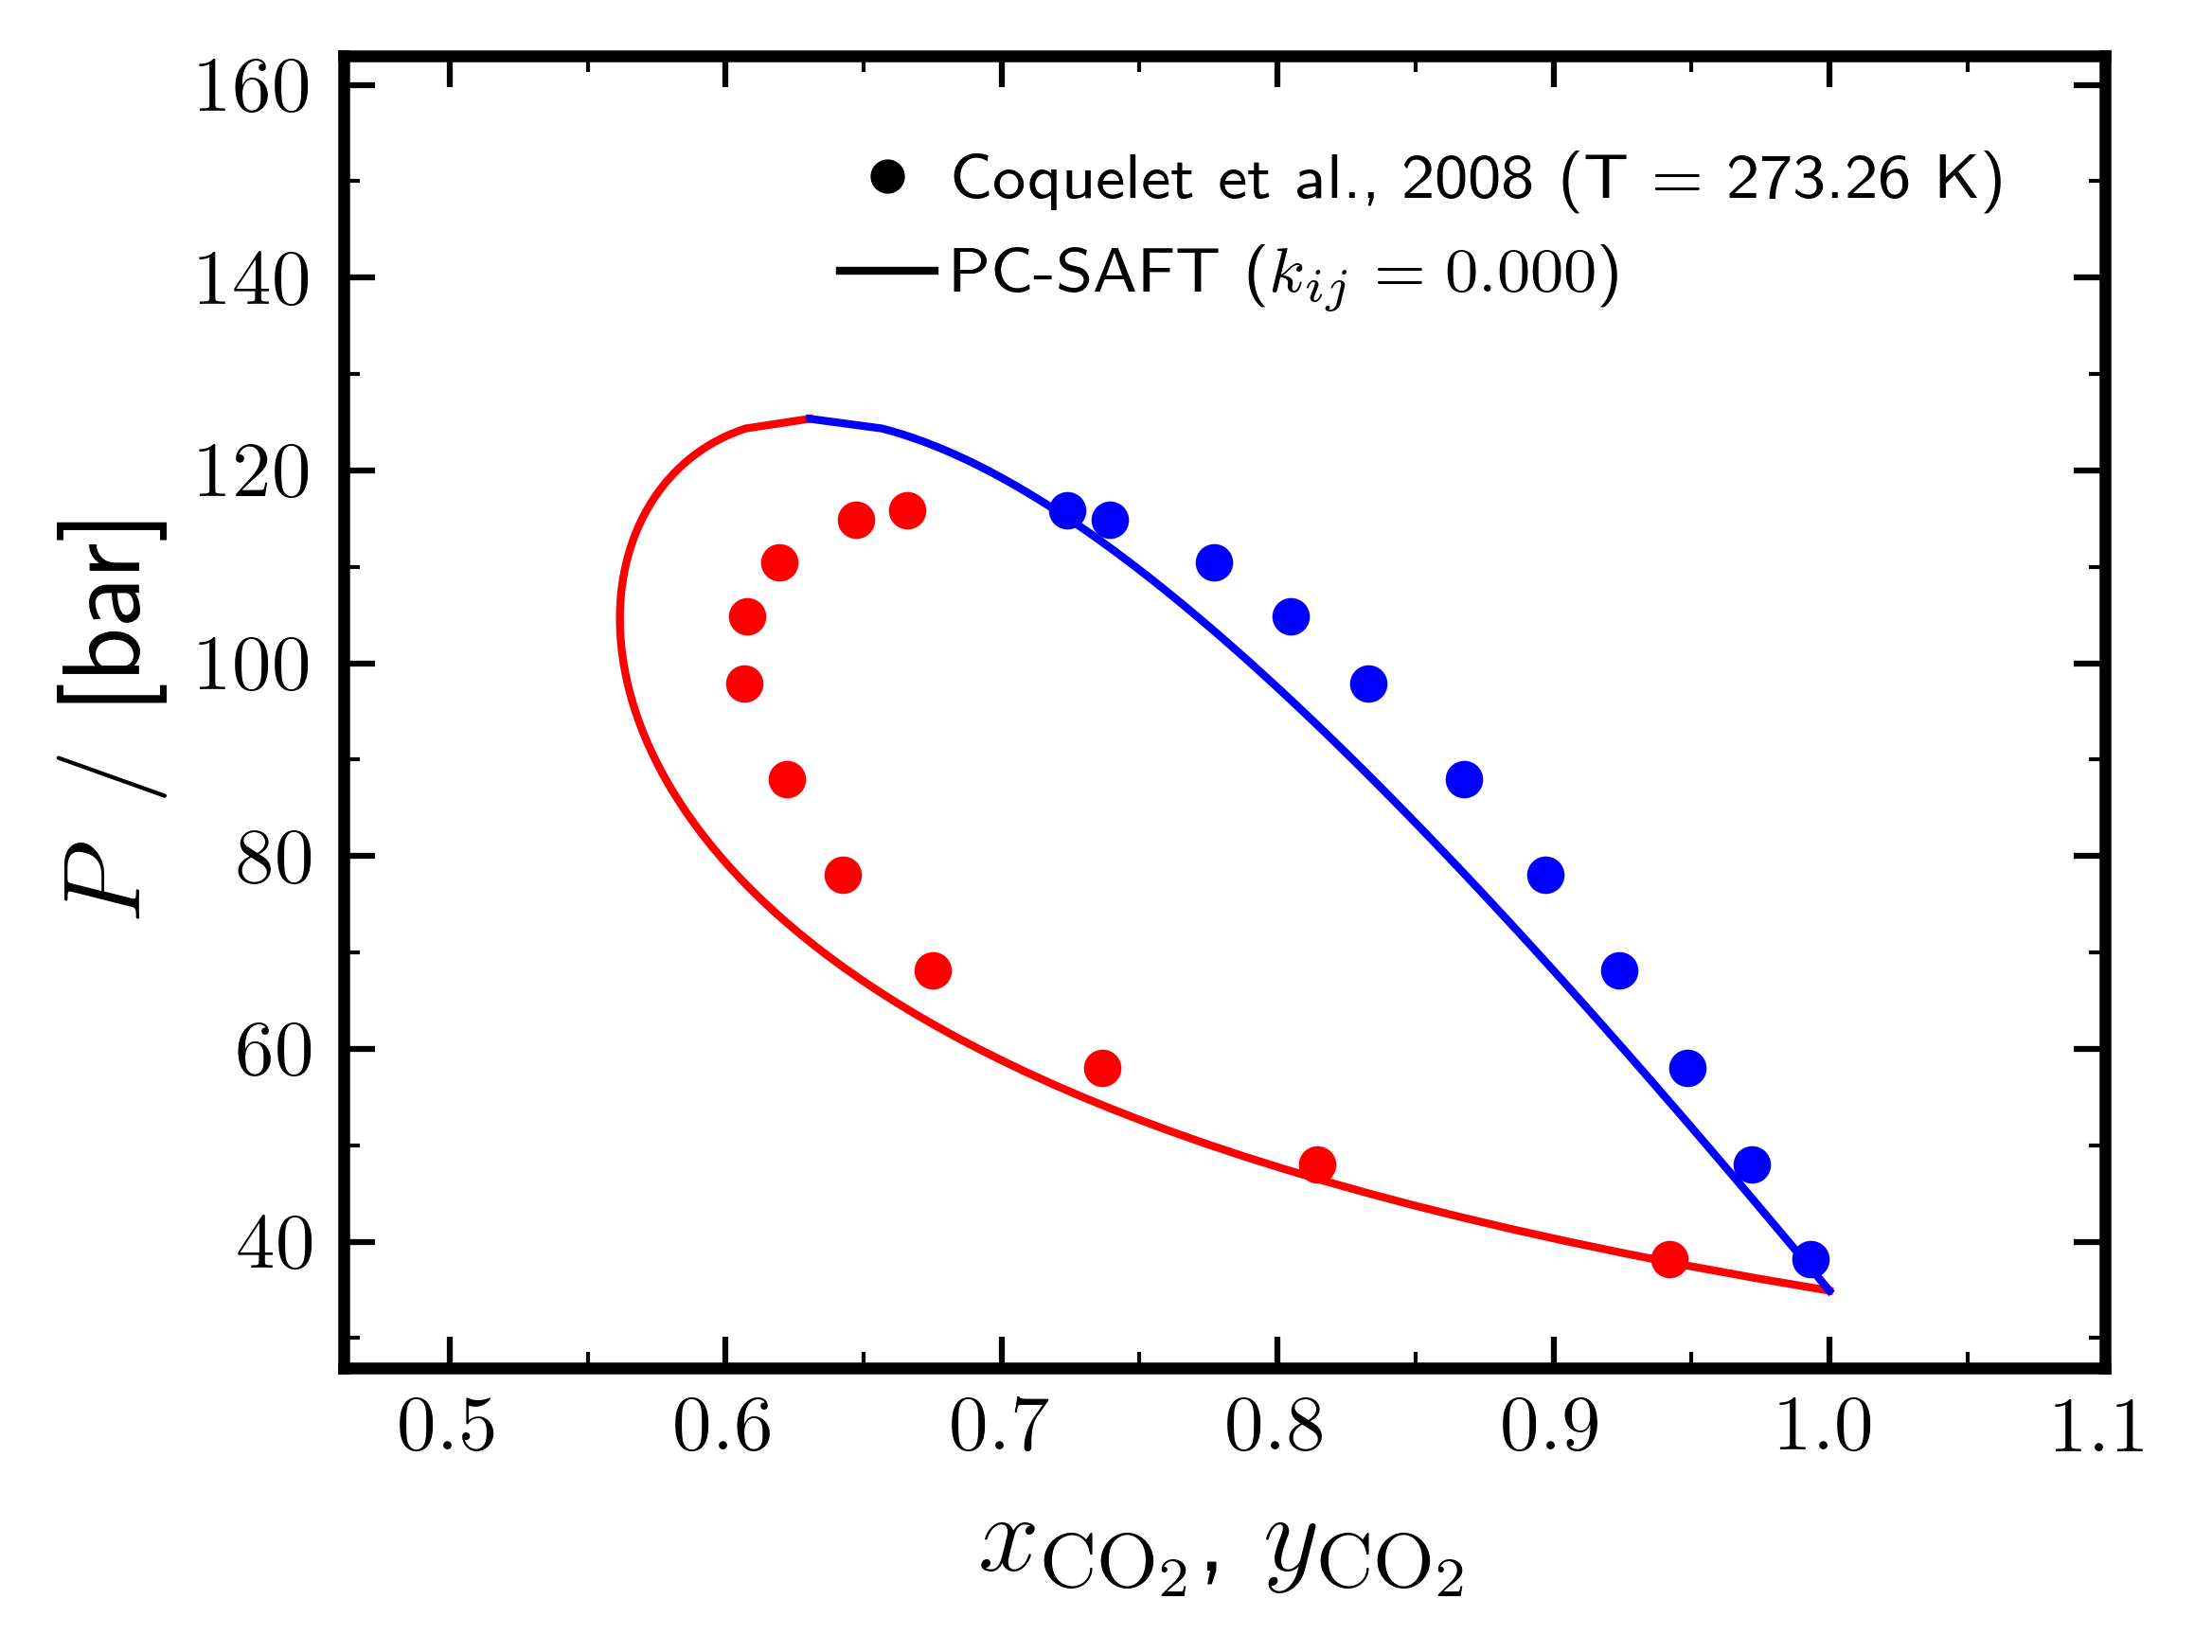

In [6]:
for T in data['t_K'].unique():
    VLE_PLOT(data, temperature=T, kij=0.0)
    plt.show()

In [ ]:
output_dir = "KIJ_PLOTS"

kij_distance = []

for T in data['t_K'].unique():

    isotherm = data[data['t_K'] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    isotherms = [
            feos.estimator.DataSet.binary_phase_diagram
        (
            T*si.KELVIN, 
            isotherm.p_bar.values * si.BAR, 
            isotherm.x1_AR.values,
            isotherm.y1_AR.values,
            npoints=100
        )
    ]

    estimator = feos.Estimator(isotherms, weights=[1], losses=[feos.Loss.linear()])
    
    fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
    
    kij_distance.append(fitted_kij[0])

    mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100

    kij_file = os.path.join(output_dir, "kij_distance.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow([T, fitted_kij[0], mard_distance.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij[0]:.6f}\033[0m")
    
    print(f"MARD (distance,   k_ij = {fitted_kij[0]:>6.4}) = {mard_distance.mean():>8.4} %")

AttributeError: module 'feos' has no attribute 'estimator'